# Accessing Lightning2EarthCARE data collections

This notebook demonstrates how to access and query Lightning2EarthCARE data collections stored in object storage. It includes examples for locating and loading data from different collections.

The project provides three related datasets describing lightning activity in the context of EarthCARE observations:

**1. EarthCARE-frame lightning** – lightning groups collocated with individual EarthCARE MSI-like frames, including activity within the frame and a surrounding 0.5° box within ±1 hour of overpass time.

**2. EarthCARE along-track lightning counts** – lightning statistics referenced to EarthCARE CPR samples along the nadir track, based on counts within defined spatial and temporal windows.

**3. EarthCARE lightning storm catalogue** – lightning clusters sampled along the EarthCARE nadir track by CPR and ATLID, with both cluster-level properties and time-evolving lightning activity around the overpass.

All datasets are distributed as Parquet files, with MTG-LI and GOES-GLM observations provided separately where relevant.

In [1]:
# Imports and storage configuration
import geopandas as gpd
import pandas as pd
import pystac

# setup bucket access
bucket = 's3://EarthCODE/'
endpoint_url = "https://s3.waw4-1.cloudferro.com"
region_name = "eu-west-2"
prefix = 'OSCAssets/storm-data/'

## EarthCARE along-track lightning counts & lightning storm catalogue collections

These collections can be accessed directly by loading the corresponding parquet files.

For the EarthCARE along-track lightning counts collection, there are two files, one for each lightning source:
- `EC_track_lightning_GLM.parquet`
- `EC_track_lightning_LI.parquet`

For the storm catalogue, there are two complementary files:
- `EC_lightning_clusters.parquet` — cluster summary information
- `EC_lightning_cluster_evolution.parquet` — time-evolution information for each cluster

In [2]:
%pip install s3fs

Note: you may need to restart the kernel to use updated packages.


In [3]:
selected_file = 'EC_lightning_clusters.parquet'
earthcare_id = "01101E"

gdf = gpd.read_parquet(
    f"{bucket}{prefix}{selected_file}",
    storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
    },
    # optional filtering
    #filters=[('earthcare_id', "==", earthcare_id)],
)
gdf

,unique_id,earthcare_id,source,parent_cluster_id,cluster_id,surface_type,peak_datetime,peak_lat,peak_lon,peak_lightning,...,cluster_area_km2,cluster_mean_lat,cluster_mean_lon,cluster_dist_km,first_lightning_min,last_lightning_min,duration_min,travel_km,missing_peak_minutes,geometry
0,00998A_LI_1,00998A,LI,0,1,land,2024-08-01 02:02:30.389795072+00:00,16.094421,-2.025091,20,...,2275.0,15.950360,-2.304759,32.348526,-60,60,121,102.981954,0.0,POINT (-2.02509 16.09442)
1,00998A_LI_2,00998A,LI,0,2,land,2024-08-01 02:02:42.115575296+00:00,16.852549,-2.174265,4,...,1400.0,16.629986,-2.355111,23.524247,-60,60,121,108.432420,0.0,POINT (-2.17426 16.85255)
2,01001A_GLM_4,01001A,GLM,28,4,water,2024-08-01 06:40:47.604159104+00:00,17.629013,-71.802147,124,...,825.0,17.618340,-71.763763,3.777234,-60,56,117,63.281760,0.0,POINT (-71.80215 17.62901)
3,01002A_GLM_0,01002A,GLM,3,0,water,2024-08-01 08:12:27.124881920+00:00,13.853670,-94.217842,1,...,150.0,13.882587,-94.184761,4.133024,-10,4,15,8.129193,0.0,POINT (-94.21784 13.85367)
4,01002A_GLM_12,01002A,GLM,54,12,land,2024-08-01 08:13:38.263145472+00:00,18.453066,-95.122635,9,...,275.0,18.452801,-95.116257,0.673681,-60,60,121,22.726804,0.0,POINT (-95.12263 18.45307)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6066,09534E_LI_4,09534E,LI,56,4,land,2026-01-31 17:07:09.683696256+00:00,-18.824217,-50.095688,14,...,1250.0,-18.823709,-50.038826,5.870741,-45,60,106,69.926199,0.0,POINT (-50.09569 -18.82422)
6067,09534E_LI_6,09534E,LI,70,6,land,2026-01-31 17:07:05.546615424+00:00,-18.557056,-50.041908,8,...,700.0,-18.442488,-50.099857,8.394344,-60,12,73,65.009785,0.0,POINT (-50.04191 -18.55706)
6068,09534F_GLM_0,09534F,GLM,2,0,water,2026-01-31 17:15:08.084680064+00:00,-49.505413,-57.953377,2,...,3075.0,-49.668526,-57.871700,9.853478,-60,50,111,196.086276,0.0,POINT (-57.95338 -49.50541)
6069,09534F_GLM_9,09534F,GLM,78,9,land,2026-01-31 17:08:42.100918144+00:00,-24.786068,-51.331825,9,...,475.0,-24.781071,-51.428013,9.637988,-60,60,121,84.619977,0.0,POINT (-51.33183 -24.78607)


## Displaying metadata

Load STAC metadata and display column descriptions for a selected file

In [4]:
COLLECTIONS = [
    "earthcare-storm-catalogue",
    "earthcare-along-track-lightning",
    "earthcare-frame-lightning",
]

def load_item_from_known_collections(endpoint_url: str, selected_file: str) -> pystac.Item:
    item_id = selected_file.removesuffix(".parquet")
    for c in COLLECTIONS:
        try:
            return pystac.Item.from_file(
                f"{endpoint_url}/EarthCODE/Catalogs/storm-data/{c}/{item_id}/{item_id}.json"
            )
        except Exception:
            pass
    raise FileNotFoundError(item_id)

In [5]:
selected_file_track = 'EC_track_lightning_LI.parquet'
earthcare_id = "01101E"

gdf_track = gpd.read_parquet(
    f"{bucket}{prefix}{selected_file_track}",
    storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
    },
    # optional filtering
    filters=[('earthcare_id', "==", earthcare_id)],
)
gdf_track

,cluster_id,lightning_count_2p5,lightning_count_5,time,land_flag,earthcare_id,source,geometry
0,0,0,0,2024-08-07 17:49:37.225584768,1,01101E,LI,POINT (-59.20646 -18.70222)
1,1,0,0,2024-08-07 17:49:37.225584768,1,01101E,LI,POINT (-59.20646 -18.70222)
2,2,0,0,2024-08-07 17:49:37.225584768,1,01101E,LI,POINT (-59.20646 -18.70222)
3,0,0,0,2024-08-07 17:49:37.056738560,1,01101E,LI,POINT (-59.20428 -18.69132)
4,1,0,0,2024-08-07 17:49:37.056738560,1,01101E,LI,POINT (-59.20428 -18.69132)
...,...,...,...,...,...,...,...,...
14695,1,0,0,2024-08-07 17:39:19.217130368,0,01101E,LI,POINT (-51.54823 21.26941)
14696,2,0,0,2024-08-07 17:39:19.217130368,0,01101E,LI,POINT (-51.54823 21.26941)
14697,0,0,0,2024-08-07 17:39:19.354470528,0,01101E,LI,POINT (-51.55005 21.26054)
14698,1,0,0,2024-08-07 17:39:19.354470528,0,01101E,LI,POINT (-51.55005 21.26054)


<Axes: >

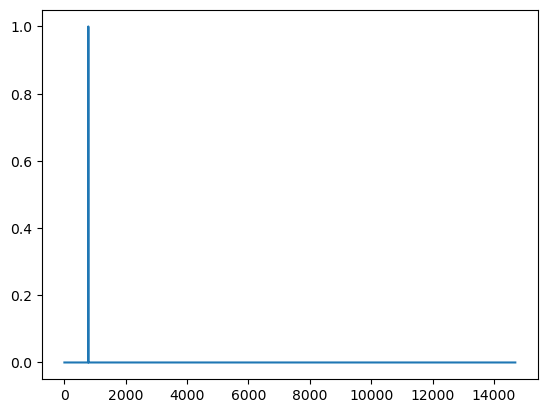

In [6]:
gdf_track.lightning_count_2p5.plot()

<Axes: >

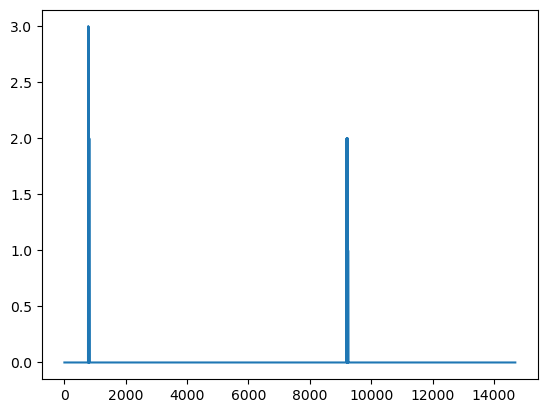

In [7]:
gdf_track.lightning_count_5.plot()

In [8]:
# display columns for the selected_file
item = load_item_from_known_collections(endpoint_url, selected_file)
cols = item.properties["parquet:columns"]
for name, desc in cols.items():
    print(f"{name} : {desc}")

unique_id : Unique identifier of the lightning cluster (earthcare_id + source + cluster_id)
earthcare_id : Orbit/frame identifier of the EarthCARE overpass
source : Lightning data source: LI (MTG) or GLM (GOES)
parent_cluster_id : Parent lightning cluster identifier
cluster_id : Lightning cluster identifier
surface_type : Surface classification at cluster location (land, water, coast)
peak_datetime : Time of CPR sample with maximum lightning activity
peak_lat : Latitude of CPR sample with maximum lightning activity
peak_lon : Longitude of CPR sample with maximum lightning activity
peak_lightning : Maximum lightning group count at a CPR sample
nadir_lightning : Lightning group count within ±2.5 min and ±2.5 km of CPR nadir track
cluster_lightning : Lightning group count within ±2.5 min of CPR peak time (any distance)
cluster_area_km2 : Area of cluster in km2
cluster_mean_lat : Mean latitude of lightning groups within ±2.5 min of CPR peak time
cluster_mean_lon : Mean longitude of lightni

In [9]:
# display columns for the selected_file
item = load_item_from_known_collections(endpoint_url, selected_file_track)
cols = item.properties["parquet:columns"]
for name, desc in cols.items():
    print(f"{name} : {desc}")

lightning_count_2p5 : {'long_name': 'Lightning groups count per cluster within 2.5 km radius and ±2.5 min time window around each CPR sample', 'units': '1'}
lightning_count_5 : {'long_name': 'Lightning groups count per cluster within 5 km radius and ±5 min time window around each CPR sample', 'units': '1'}
cpr : {'long_name': 'EarthCARE CPR sample index'}
cluster_id : {'long_name': 'Cluster identifier'}
latitude : {'long_name': 'CPR nadir latitude', 'units': 'degrees_north'}
longitude : {'long_name': 'CPR nadir longitude', 'units': 'degrees_east'}
time : {'long_name': 'CPR observation time'}
land_flag : {'long_name': 'CPR land/water flag', 'definition': '1 = land, 0 = not land', 'units': '1'}


In [10]:
from pystac_client import Client
import fsspec
import xarray as xr
import matplotlib.pyplot as plt
from tqdm import tqdm
import requests
from IPython.display import Image, display
import pathlib

In [11]:
catalog_url = 'https://catalog.maap.eo.esa.int/catalogue/'
catalog = Client.open(catalog_url)

In [12]:
# Select one or more collection(s)
EC_COLLECTION = ['EarthCAREL2Validated_MAAP']
#EC_multiple_COLLECTIONS = ['EarthCAREL2Validated_MAAP', 'EarthCAREL1Validated_MAAP']

In [13]:
search = catalog.search(
    collections=EC_COLLECTION, 
    filter="(productType = 'ACM_CAP_2B') and orbitNumber = 01101 and frame = 'E'", # For example filter by product type and orbitNumber. Use boolean logic for multi-filter queries

    #bbox = [0, -20, 10, -10], # Filter by area 
    #datetime = ['2025-10-01T00:00:00Z', '2025-12-31T23:59:59Z'], # Filter by date
    method = 'GET', # This is necessary 
    max_items=1  # Adjust as needed, given the large amount of products it is recommended to set a limit if especially if you display results in pandas dataframe or similiar
)
items = list(search.items()) # Get all items as a list
results = search.matched()

print(f"{results} items found that matched the query.")
print(f"Accessing {len(items)} items (limited by max_items).")

1 items found that matched the query.
Accessing 1 items (limited by max_items).


In [14]:
items[0]

<Item id=ECA_EXBA_ACM_CAP_2B_20240807T173855Z_20250905T182139Z_01101E>

In [15]:
# Choose the first item
ec_product = items[0]

In [18]:
import os
from pathlib import Path
import requests
import aiohttp

# --- Path to credentials.txt --- 
CREDENTIALS_FILE = (pathlib.Path.home() / "credentials.txt" ).resolve()   # Insert the .txt path

def load_credentials(file_path=CREDENTIALS_FILE):
    """Read key-value pairs from a credentials file into a dictionary."""
    creds = {}
    if not file_path.exists():
        raise FileNotFoundError(f"Credentials file not found: {file_path}")
    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            if "=" not in line:
                continue
            key, value = line.split("=", 1)
            creds[key.strip()] = value.strip()
    return creds


# --- ESA MAAP API ---

def get_token():
    """Use OFFLINE_TOKEN to fetch a short-lived access token."""
    creds = load_credentials()

    OFFLINE_TOKEN = creds.get("OFFLINE_TOKEN")
    CLIENT_ID = creds.get("CLIENT_ID")
    CLIENT_SECRET = creds.get("CLIENT_SECRET")
    print(CLIENT_SECRET)

    if not all([OFFLINE_TOKEN, CLIENT_ID, CLIENT_SECRET]):
        raise ValueError("Missing OFFLINE_TOKEN, CLIENT_ID, or CLIENT_SECRET in credentials file")

    url = "https://iam.maap.eo.esa.int/realms/esa-maap/protocol/openid-connect/token"
    data = {
        "client_id": CLIENT_ID,
        "client_secret": CLIENT_SECRET,
        "grant_type": "refresh_token",
        "refresh_token": OFFLINE_TOKEN,
        "scope": "offline_access openid"
    }

    response = requests.post(url, data=data)
    response.raise_for_status()

    response_json = response.json()
    access_token = response_json.get('access_token')

    if not access_token:
        raise RuntimeError("Failed to retrieve access token from IAM response")

    return access_token

In [19]:
token = get_token();

p1eL7uonXs6MDxtGbgKdPVRAmnGxHpVE


In [18]:
# Fetching the url of the desired file
ds_url = ec_product.assets.get('enclosure_h5').href  # Updated to enclosure_h5
print(f"Dataset URL: {ds_url}")

Dataset URL: https://catalog.maap.eo.esa.int/data/earthcare-pdgs-01/EarthCARE/ACM_CAP_2B/BA/2024/08/07/ECA_EXBA_ACM_CAP_2B_20240807T173855Z_20250905T182139Z_01101E/ECA_EXBA_ACM_CAP_2B_20240807T173855Z_20250905T182139Z_01101E/ECA_EXBA_ACM_CAP_2B_20240807T173855Z_20250905T182139Z_01101E.h5


In [19]:
io_params = {
    "fsspec_params": {
        "cache_type": "blockcache",
        "block_size": 8 * 1024 * 1024
    },
    "h5py_params": {
        "driver_kwds": {
            "rdcc_nbytes": 8 * 1024 * 1024
        }
    }
}

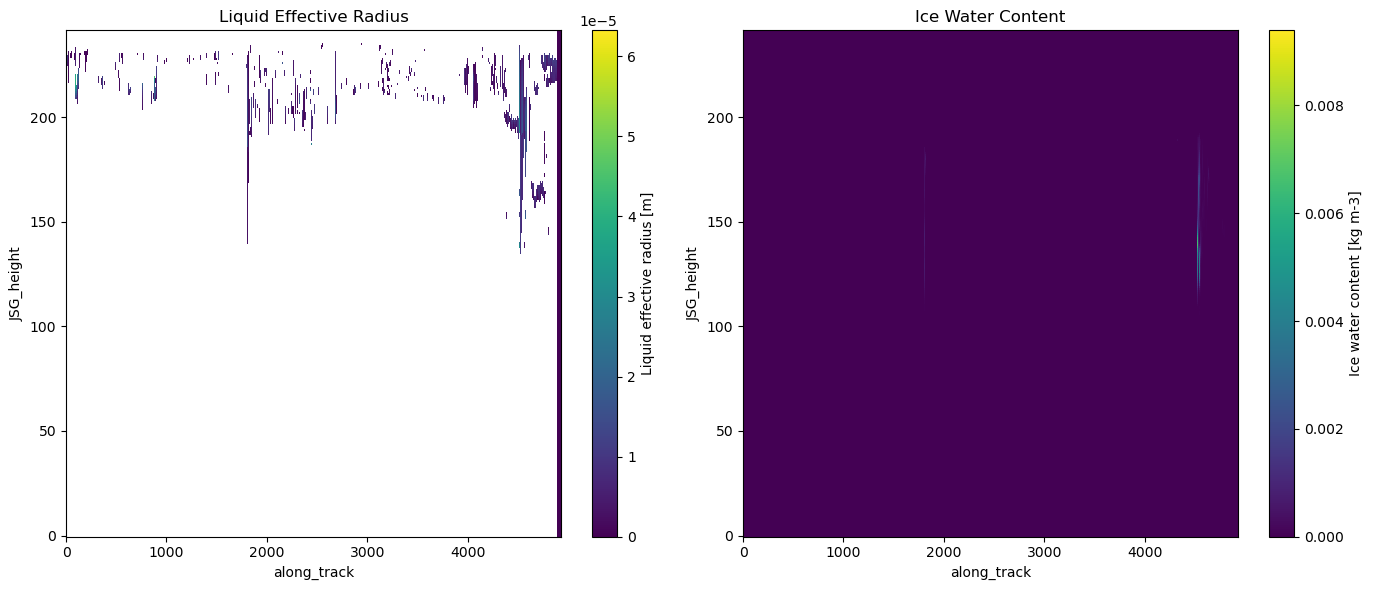

In [20]:
fs = fsspec.filesystem(
    "https", 
    headers={"Authorization": f"Bearer {token}"}, 
    **io_params["fsspec_params"]  )

# Open the file and read it into an xarray Dataset
with fs.open(ds_url, "rb") as f:
    ds = xr.open_dataset(f, 
                         engine="h5netcdf", 
                         **io_params["h5py_params"],  
                         group="ScienceData")
    # Do something with ds! Here we plot two variables as an example.
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot Cloud Water Path
    ds["liquid_effective_radius"].T.plot(ax=axes[0])
    axes[0].set_title("Liquid Effective Radius")

    # Plot Cloud Top Temperature
    ds["ice_water_content"].T.plot(ax=axes[1])
    axes[1].set_title("Ice Water Content")

    plt.tight_layout()
    plt.show()
    

In [21]:
ds

<xarray.Dataset> Size: 559MB
Dimensions:                                                         (
                                                                     along_track: 4930,
                                                                     JSG_height: 242,
                                                                     MSI_longwave_channel: 3,
                                                                     MSI_shortwave_channel: 1)
Dimensions without coordinates: along_track, JSG_height, MSI_longwave_channel,
                                MSI_shortwave_channel
Data variables: (12/192)
    time                                                            (along_track) datetime64[ns] 39kB ...
    latitude                                                        (along_track) float64 39kB ...
    longitude                                                       (along_track) float64 39kB ...
    height                                                          (along_track, JSG_height) float32 5MB ...
    geoid_offset                                                    (along_track) float32 20kB ...
    elevation                                                       (along_track) float32 20kB ...
    ...                                                              ...
    MSI_shortwave_observation_variable_count                        (along_track) int32 20kB ...
    MSI_shortwave_cost_function                                     (along_track) float32 20kB ...
    MSI_shortwave_wavelength                                        (MSI_shortwave_channel) float32 4B ...
    MSI_shortwave_albedo_forward                                    (along_track, MSI_shortwave_channel) float32 20kB ...
    MSI_shortwave_albedo                                            (along_track, MSI_shortwave_channel) float32 20kB ...
    MSI_shortwave_albedo_assimilation_status                        (along_track) int8 5kB ...

ACM-CAP
time
latitude
longitude
height
tropopause_height
quality_status
ice_water_content
ice_mass_flux
ice_effective_radius
ice_median_volume_diameter
ice_riming_factor
rain_rate
rain_water_content
rain_median_volume_diameter
liquid_water_content
liquid_number_concentration
liquid_effective_radius

In [22]:
search = catalog.search(
    collections=EC_COLLECTION, 
    filter="(productType = 'CPR_CD__2A') and orbitNumber = 01101 and frame = 'E'", # For example filter by product type and orbitNumber. Use boolean logic for multi-filter queries

    #bbox = [0, -20, 10, -10], # Filter by area 
    #datetime = ['2025-10-01T00:00:00Z', '2025-12-31T23:59:59Z'], # Filter by date
    method = 'GET', # This is necessary 
    max_items=1  # Adjust as needed, given the large amount of products it is recommended to set a limit if especially if you display results in pandas dataframe or similiar
)
items = list(search.items()) # Get all items as a list

In [23]:
fs = fsspec.filesystem(
    "https", 
    headers={"Authorization": f"Bearer {token}"}, 
    **io_params["fsspec_params"]  )

ds_url = items[0].assets.get('enclosure_h5').href  # Updated to enclosure_h5

# Open the file and read it into an xarray Dataset
with fs.open(ds_url, "rb") as f:
    ds = xr.open_dataset(f, 
                         engine="h5netcdf", 
                         **io_params["h5py_params"],  
                         group="ScienceData")
    

In [24]:
ds

<xarray.Dataset> Size: 90MB
Dimensions:                                                 (along_track: 4900,
                                                             CPR_height: 218)
Dimensions without coordinates: along_track, CPR_height
Data variables: (12/34)
    time                                                    (along_track) datetime64[ns] 39kB ...
    latitude                                                (along_track) float64 39kB ...
    longitude                                               (along_track) float64 39kB ...
    height                                                  (along_track, CPR_height) float32 4MB ...
    geoid_offset                                            (along_track) float32 20kB ...
    surface_elevation                                       (along_track) float32 20kB ...
    ...                                                      ...
    doppler_velocity_and_spectrum_width_integrated_error    (along_track, CPR_height) float32 4MB ...
    doppler_velocity_and_spectrum_width_integrated_status   (along_track, CPR_height) float32 4MB ...
    doppler_velocity_best_estimate                          (along_track, CPR_height) float32 4MB ...
    sedimentation_velocity_best_estimate                    (along_track, CPR_height) float32 4MB ...
    sedimentation_velocity_best_estimate_error              (along_track, CPR_height) float32 4MB ...
    sedimentation_velocity_best_estimate_status             (along_track, CPR_height) float32 4MB ...

C-CD
time
latitude
longitude
height
doppler_velocity_best_estimate
sedimentation_velocity_best_estimate
spectrum_width_integrated

In [25]:
search = catalog.search(
    collections=EC_COLLECTION, 
    filter="(productType = 'CPR_CD__2A') and orbitNumber = 01101 and frame = 'E'", # For example filter by product type and orbitNumber. Use boolean logic for multi-filter queries
    method = 'GET', # This is necessary 
    max_items=1  # Adjust as needed, given the large amount of products it is recommended to set a limit if especially if you display results in pandas dataframe or similiar
)
items = list(search.items()) # Get all items as a list
ccd_ds = xr.open_dataset(
    fs.open(items[0].assets.get('enclosure_h5').href, "rb"), 
    engine="h5netcdf", 
    **io_params["h5py_params"],  
    group="ScienceData"
)

In [26]:
search = catalog.search(
    collections=EC_COLLECTION, 
    filter="(productType = 'ACM_CAP_2B') and orbitNumber = 01101 and frame = 'E'", # For example filter by product type and orbitNumber. Use boolean logic for multi-filter queries
    method = 'GET', # This is necessary 
    max_items=1  # Adjust as needed, given the large amount of products it is recommended to set a limit if especially if you display results in pandas dataframe or similiar
)
items = list(search.items()) # Get all items as a list
acmcap_ds = xr.open_dataset(
    fs.open(items[0].assets.get('enclosure_h5').href, "rb"), 
    engine="h5netcdf", 
    **io_params["h5py_params"],  
    group="ScienceData"
)

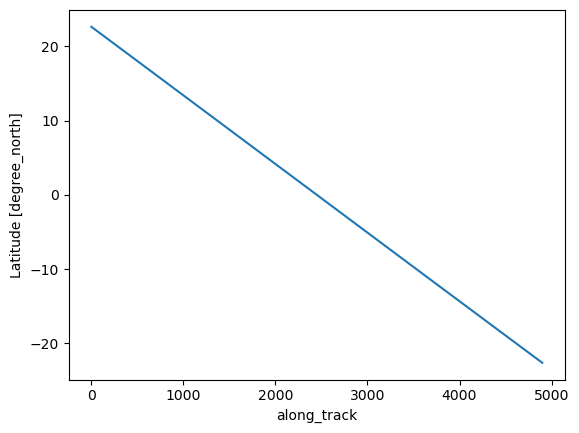

In [27]:
ccd_ds.latitude.plot()

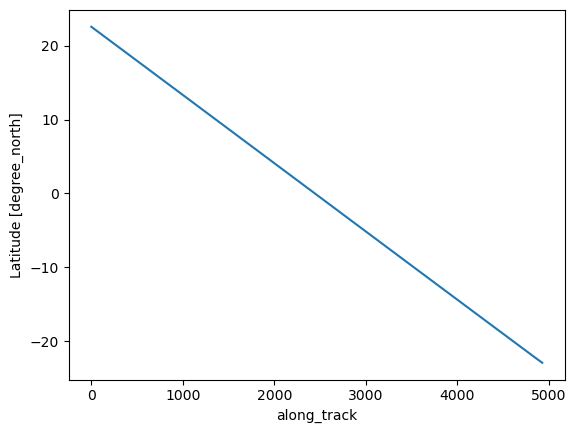

In [28]:
acmcap_ds.latitude.plot()

In [31]:
ccd_ds.height.min(), ccd_ds.height.max()

(<xarray.DataArray 'height' ()> Size: 4B
 array(-1324.6123, dtype=float32),
 <xarray.DataArray 'height' ()> Size: 4B
 array(20278.502, dtype=float32))

In [32]:
acmcap_ds.height.min(), acmcap_ds.height.max()

(<xarray.DataArray 'height' ()> Size: 4B
 array(-499.99228, dtype=float32),
 <xarray.DataArray 'height' ()> Size: 4B
 array(40310.57, dtype=float32))

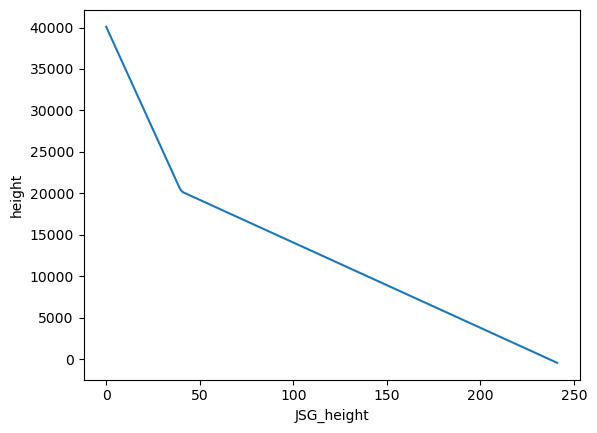

In [35]:
acmcap_ds.height.mean("along_track").plot()

In [37]:
import numpy as np

In [45]:
np.where(acmcap_ds.height<2e4)[1].min()

np.int64(42)

In [46]:
np.where(acmcap_ds.height.data>0)[1].max()

np.int64(237)

In [48]:
acmcap_ds.isel(JSG_height=slice(42,238))

<xarray.Dataset> Size: 453MB
Dimensions:                                                         (
                                                                     along_track: 4930,
                                                                     JSG_height: 196,
                                                                     MSI_longwave_channel: 3,
                                                                     MSI_shortwave_channel: 1)
Dimensions without coordinates: along_track, JSG_height, MSI_longwave_channel,
                                MSI_shortwave_channel
Data variables: (12/192)
    time                                                            (along_track) datetime64[ns] 39kB ...
    latitude                                                        (along_track) float64 39kB ...
    longitude                                                       (along_track) float64 39kB ...
    height                                                          (along_track, JSG_height) float32 4MB ...
    geoid_offset                                                    (along_track) float32 20kB ...
    elevation                                                       (along_track) float32 20kB ...
    ...                                                              ...
    MSI_shortwave_observation_variable_count                        (along_track) int32 20kB ...
    MSI_shortwave_cost_function                                     (along_track) float32 20kB ...
    MSI_shortwave_wavelength                                        (MSI_shortwave_channel) float32 4B ...
    MSI_shortwave_albedo_forward                                    (along_track, MSI_shortwave_channel) float32 20kB ...
    MSI_shortwave_albedo                                            (along_track, MSI_shortwave_channel) float32 20kB ...
    MSI_shortwave_albedo_assimilation_status                        (along_track) int8 5kB ...

In [53]:
acmcap_ds.height.where(np.logical_and(acmcap_ds.height>0 , acmcap_ds.height<2e4), drop=True)

<xarray.DataArray 'height' (along_track: 4930, JSG_height: 196)> Size: 4MB
array([[19989.766  , 19886.875  , 19783.982  , ...,   131.81671,
           28.92631,         nan],
       [19988.451  , 19885.559  , 19782.668  , ...,   130.50166,
           27.61125,         nan],
       [19996.496  , 19893.605  , 19790.713  , ...,   138.5469 ,
           35.65649,         nan],
       ...,
       [        nan, 19953.396  , 19850.506  , ...,   198.30865,
           95.41809,         nan],
       [        nan, 19956.67   , 19853.78   , ...,   201.58176,
           98.69118,         nan],
       [        nan, 19959.127  , 19856.236  , ...,   204.0397 ,
          101.14913,         nan]], shape=(4930, 196), dtype=float32)
Dimensions without coordinates: along_track, JSG_height
Attributes:
    long_name:  Height
    units:      m

In [54]:
ccd_ds.height.where(np.logical_and(ccd_ds.height>0 , ccd_ds.height<2e4), drop=True)

<xarray.DataArray 'height' (along_track: 4900, CPR_height: 201)> Size: 4MB
array([[         nan, 19935.383   , 19835.453   , ...,   249.0117  ,
          149.08089 ,    49.150063],
       [         nan, 19934.217   , 19834.287   , ...,   247.8461  ,
          147.91528 ,    47.984467],
       [         nan, 19933.053   , 19833.121   , ...,   246.68118 ,
          146.75037 ,    46.819542],
       ...,
       [         nan, 19936.146   , 19836.217   , ...,   249.77606 ,
          149.84525 ,    49.91443 ],
       [         nan, 19939.012   , 19839.082   , ...,   252.64128 ,
          152.71046 ,    52.779648],
       [         nan, 19941.879   , 19841.947   , ...,   255.50708 ,
          155.57626 ,    55.64544 ]], shape=(4900, 201), dtype=float32)
Dimensions without coordinates: along_track, CPR_height
Attributes:
    long_name:  Height above WGS84 ellipsoid
    units:      m

In [55]:
pip install stratify

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 51.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [56]:
import stratify

In [57]:
acmcap_ds.height

<xarray.DataArray 'height' (along_track: 4930, JSG_height: 242)> Size: 5MB
array([[39829.203  , 39333.45   , 38837.695  , ...,  -279.74487,  -382.63528,
         -485.52567],
       [39827.89   , 39332.137  , 38836.383  , ...,  -281.05994,  -383.95035,
         -486.84073],
       [39835.934  , 39340.18   , 38844.426  , ...,  -273.0147 ,  -375.9051 ,
         -478.79547],
       ...,
       [40288.625  , 39792.867  , 39297.11   , ...,  -213.25359,  -316.14413,
         -419.03467],
       [40291.89   , 39796.137  , 39300.383  , ...,  -209.9805 ,  -312.87103,
         -415.7616 ],
       [40294.355  , 39798.598  , 39302.84   , ...,  -207.52254,  -310.4131 ,
         -413.30362]], shape=(4930, 242), dtype=float32)
Dimensions without coordinates: along_track, JSG_height
Attributes:
    long_name:  Height
    units:      m

In [65]:
stratify.interpolate(
    np.arange(50,2e4,100)[::-1],
    acmcap_ds.height.values,
    acmcap_ds.ice_water_content.values,
    axis=1,
    rising=False
)
    

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(4930, 200), dtype=float32)

In [68]:
stratify.interpolate(
    np.arange(50,2e4,100)[::-1],
    ccd_ds.height.values,
    ccd_ds.doppler_velocity_best_estimate.values,
    axis=1,
    rising=False
)
    

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(4900, 200), dtype=float32)

In [70]:
import matplotlib.pyplot as plt

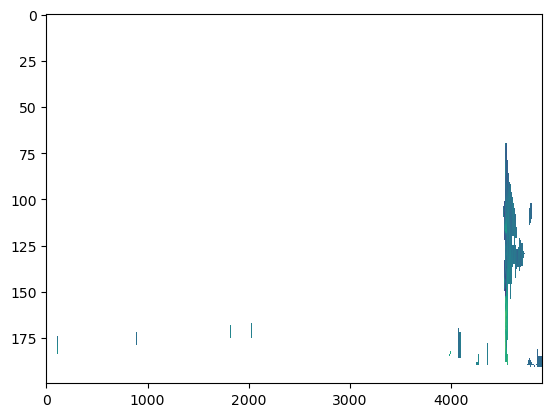

In [72]:
plt.imshow(
    stratify.interpolate(
        np.arange(50,2e4,100)[::-1],
        ccd_ds.height.values,
        ccd_ds.doppler_velocity_best_estimate.values,
        axis=1,
        rising=False
    ).T,
    aspect="auto"
)

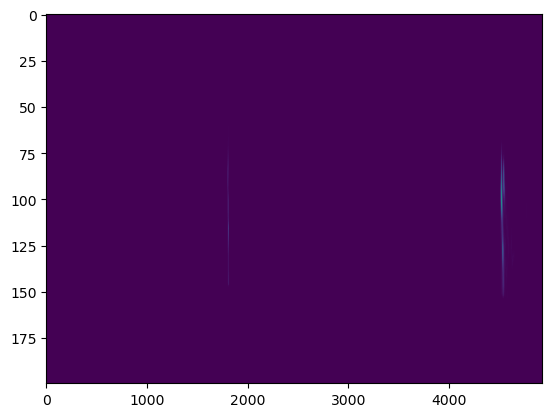

In [73]:
plt.imshow(
    stratify.interpolate(
        np.arange(50,2e4,100)[::-1],
        acmcap_ds.height.values,
        acmcap_ds.ice_water_content.values,
        axis=1,
        rising=False
    ).T,
    aspect="auto"
)

In [83]:
acmcap_ds.latitude.isel(along_track=0).item(), acmcap_ds.longitude.isel(along_track=0).item(), acmcap_ds.time.isel(along_track=0).values

(22.581176650386535,
 -51.27779166543269,
 np.datetime64('2024-08-07T17:38:58.904198144'))

In [95]:
i=12
ccd_ds.latitude.isel(along_track=i).item(), ccd_ds.longitude.isel(along_track=i).item(), ccd_ds.time.isel(along_track=i).values


(22.516610656919127,
 -51.29118375658146,
 np.datetime64('2024-08-07T17:38:59.903881728'))

In [86]:
ccd_ds

<xarray.Dataset> Size: 90MB
Dimensions:                                                 (along_track: 4900,
                                                             CPR_height: 218)
Dimensions without coordinates: along_track, CPR_height
Data variables: (12/34)
    time                                                    (along_track) datetime64[ns] 39kB ...
    latitude                                                (along_track) float64 39kB ...
    longitude                                               (along_track) float64 39kB ...
    height                                                  (along_track, CPR_height) float32 4MB ...
    geoid_offset                                            (along_track) float32 20kB ...
    surface_elevation                                       (along_track) float32 20kB ...
    ...                                                      ...
    doppler_velocity_and_spectrum_width_integrated_error    (along_track, CPR_height) float32 4MB ...
    doppler_velocity_and_spectrum_width_integrated_status   (along_track, CPR_height) float32 4MB ...
    doppler_velocity_best_estimate                          (along_track, CPR_height) float32 4MB ...
    sedimentation_velocity_best_estimate                    (along_track, CPR_height) float32 4MB ...
    sedimentation_velocity_best_estimate_error              (along_track, CPR_height) float32 4MB ...
    sedimentation_velocity_best_estimate_status             (along_track, CPR_height) float32 4MB ...

In [87]:
acmcap_ds

<xarray.Dataset> Size: 559MB
Dimensions:                                                         (
                                                                     along_track: 4930,
                                                                     JSG_height: 242,
                                                                     MSI_longwave_channel: 3,
                                                                     MSI_shortwave_channel: 1)
Dimensions without coordinates: along_track, JSG_height, MSI_longwave_channel,
                                MSI_shortwave_channel
Data variables: (12/192)
    time                                                            (along_track) datetime64[ns] 39kB ...
    latitude                                                        (along_track) float64 39kB ...
    longitude                                                       (along_track) float64 39kB ...
    height                                                          (along_track, JSG_height) float32 5MB ...
    geoid_offset                                                    (along_track) float32 20kB ...
    elevation                                                       (along_track) float32 20kB ...
    ...                                                              ...
    MSI_shortwave_observation_variable_count                        (along_track) int32 20kB ...
    MSI_shortwave_cost_function                                     (along_track) float32 20kB ...
    MSI_shortwave_wavelength                                        (MSI_shortwave_channel) float32 4B ...
    MSI_shortwave_albedo_forward                                    (along_track, MSI_shortwave_channel) float32 20kB ...
    MSI_shortwave_albedo                                            (along_track, MSI_shortwave_channel) float32 20kB ...
    MSI_shortwave_albedo_assimilation_status                        (along_track) int8 5kB ...

In [97]:
pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 111.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [98]:
from sklearn.neighbors import BallTree

In [99]:
cpr_ll_tree = BallTree(
    np.radians(np.stack(
        [
            ccd_ds.latitude.values, 
            ccd_ds.longitude.values,
        ], axis=1
    )), 
    metric="haversine", 
)

In [108]:
jsg_ll_tree = BallTree(
    np.radians(np.stack(
        [
            acmcap_ds.latitude.values, 
            acmcap_ds.longitude.values,
        ], axis=1
    )), 
    metric="haversine", 
)

In [114]:
distances, neighbours = jsg_ll_tree.query(
    np.radians(np.stack(
        [
            ccd_ds.latitude.values, 
            ccd_ds.longitude.values,
        ], axis=1
    ))
)

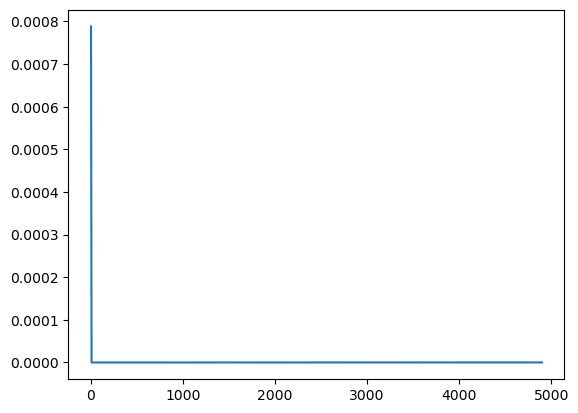

In [115]:
plt.plot(distances)

In [116]:
distances.max()

np.float64(0.0007881931826020848)

In [117]:
neighbours

array([[   0],
       [   0],
       [   0],
       ...,
       [4892],
       [4893],
       [4894]], shape=(4900, 1))

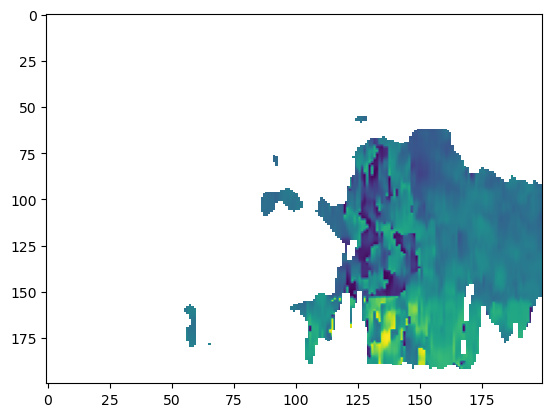

In [119]:
plt.imshow(
    stratify.interpolate(
        np.arange(50,2e4,100)[::-1],
        ccd_ds.height.values,
        ccd_ds.doppler_velocity_best_estimate.values,
        axis=1,
        rising=False
    ).T[:,4400:4600],
    aspect="auto"
)

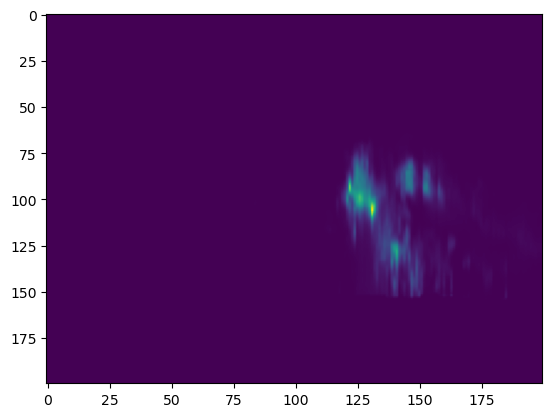

In [120]:
plt.imshow(
    stratify.interpolate(
        np.arange(50,2e4,100)[::-1],
        acmcap_ds.height.values,
        acmcap_ds.ice_water_content.values,
        axis=1,
        rising=False
    ).T[:,4400:4600],
    aspect="auto"
)

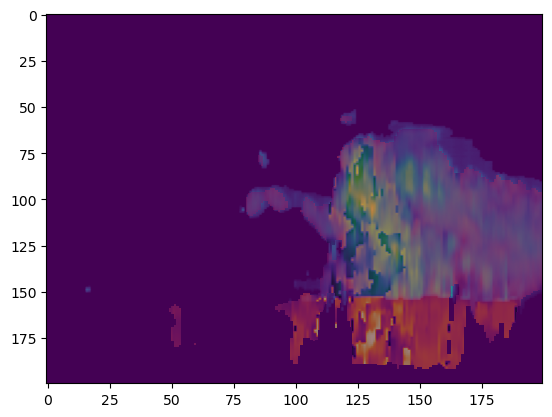

In [134]:

plt.imshow(
    stratify.interpolate(
        np.arange(50,2e4,100)[::-1],
        acmcap_ds.height.values,
        acmcap_ds.ice_water_content.values,
        axis=1,
        rising=False
    ).T[:,4400:4600]**0.25,
    aspect="auto"
)

plt.imshow(
    stratify.interpolate(
        np.arange(50,2e4,100)[::-1],
        ccd_ds.height.values,
        ccd_ds.doppler_velocity_best_estimate.values,
        axis=1,
        rising=False
    ).T[:,4406:4606],
    aspect="auto",
    alpha=0.5,
    cmap="inferno"
)